# PTCG AI Battle: Rating and Matchmaking Analysis

This notebook uses the [public Kaggle leaderboard](https://www.kaggle.com/competitions/pokemon-tcg-ai-battle/leaderboard)
and the author's own public match data (Public Episodes) to examine four topics:

1. **The rating distribution and standard deviation on the leaderboard as of August 1, 2026 (UTC)**
2. **The distribution of matchmaking times by rating band**
3. **An observation that submissions rated 1000 or higher received more public matches**
4. **The divergence between two submissions of the same deck made at nearly the same time**

> To protect privacy, this notebook does not disclose team names, opponent names, Episode IDs,
> Submission IDs, or submission descriptions. It publishes only the information needed for the
> analysis: submission times, anonymized rating trajectories for Submission A and Submission B,
> rating bands, elapsed-time buckets after submission, and aggregate counts.

## Summary

1. **Rating distribution:** Across 6,113 teams at 21:17 UTC on August 1, the mean rating was
   **622.8**, the population standard deviation was **186.6**, and the median was **637.8**.
2. **Matchmaking timing:** In most rating bands, matches were concentrated in the first
   0–2 hours after submission. For three historical submissions rated 1000 or higher,
   45–51 matches occurred in the first three hours, followed by a second concentration of
   matches 11–21 hours after submission.
3. **Difference in match volume between ratings of 1000+ and around 900:** Within one day of
   submission, the 1000+ submission received about **3.5 times** as many public matches as the
   submission rated around 900.
4. **Difference between two submissions of the same deck made at nearly the same time:** Their
   ratings diverged to **689 vs. 489 (a 200-point gap)** after the first match,
   **1011 vs. 642 (a 369-point gap)** after six matches, and
   **1150 vs. 867 (a 283-point gap)** after 48 matches. Of the 185-match difference in total
   match volume, 156 matches (about 84%) came from the difference in rematches.

Even though the two submissions used the same artifact, they did not face the same opponents,
so the rating gap cannot be interpreted as the causal effect of the first results alone.
Comparisons across rating bands are also descriptive observations involving different agents
and submission dates.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string(index=False) if hasattr(value, "to_string") else value)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["axes.unicode_minus"] = False
BLUE, NAVY, CYAN, GOLD, RED = "#2f80ed", "#17324d", "#56ccf2", "#f2c94c", "#eb5757"

In [2]:
# Public analysis data only: no team names, episode IDs, or submission IDs.

LEADERBOARD = {'snapshot_utc': '2026-08-01 21:17:47 UTC',
 'snapshot_jst': '2026-08-02 06:17:47 JST',
 'teams': 6113,
 'mean': 622.8,
 'population_stdev': 186.6,
 'median': 637.8,
 'minimum': -269.4,
 'maximum': 1262.2,
 'percentiles': {'P1': 181.2,
                 'P5': 292.9,
                 'P10': 357.3,
                 'P25': 498.9,
                 'P50': 637.8,
                 'P75': 755.2,
                 'P90': 836.1,
                 'P95': 903.8,
                 'P99': 1035.6},
 'histogram': {'<100': 13,
               '100–199.9': 74,
               '200–299.9': 253,
               '300–399.9': 468,
               '400–499.9': 725,
               '500–599.9': 1020,
               '600–699.9': 1230,
               '700–799.9': 1428,
               '800–899.9': 580,
               '900–999.9': 207,
               '1000–1099.9': 93,
               '1100–1199.9': 19,
               '1200–1299.9': 3,
               '1300+': 0}}

TIMING = [{'rating_band': '1000+',
  'submitted_at_jst': '2026-08-01 13:10:53',
  'public_games': 260,
  'first_match_hours': 0.05,
  'last_match_hours': 21.67,
  'hourly_counts': [15, 18, 18, 16, 3, 4, 11, 21, 8, 2, 3, 3, 0, 3, 2, 4, 18, 23, 28, 24, 22, 14, 0, 0, 0]},
 {'rating_band': '900',
  'submitted_at_jst': '2026-08-01 13:10:50',
  'public_games': 75,
  'first_match_hours': 0.05,
  'last_match_hours': 21.54,
  'hourly_counts': [16, 16, 16, 1, 2, 1, 2, 1, 4, 0, 2, 1, 3, 0, 1, 0, 1, 2, 2, 2, 1, 1, 0, 0, 0]},
 {'rating_band': '800',
  'submitted_at_jst': '2026-07-27 22:18:14',
  'public_games': 71,
  'first_match_hours': 0.05,
  'last_match_hours': 24.28,
  'hourly_counts': [15, 15, 12, 1, 3, 3, 2, 2, 1, 2, 1, 0, 2, 0, 0, 1, 1, 1, 1, 1, 2, 0, 3, 1, 1]},
 {'rating_band': '700',
  'submitted_at_jst': '2026-07-27 22:57:47',
  'public_games': 64,
  'first_match_hours': 0.06,
  'last_match_hours': 23.68,
  'hourly_counts': [16, 16, 5, 2, 2, 2, 3, 1, 1, 1, 0, 0, 2, 2, 2, 1, 3, 1, 1, 0, 1, 0, 0, 2, 0]},
 {'rating_band': '600',
  'submitted_at_jst': '2026-07-20 18:00:28',
  'public_games': 55,
  'first_match_hours': 0.08,
  'last_match_hours': 18.02,
  'hourly_counts': [15, 15, 8, 0, 4, 0, 1, 0, 1, 0, 1, 2, 0, 2, 4, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0]},
 {'rating_band': '500',
  'submitted_at_jst': '2026-07-17 22:55:10',
  'public_games': 35,
  'first_match_hours': 0.07,
  'last_match_hours': 12.89,
  'hourly_counts': [14, 13, 1, 0, 2, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]},
 {'rating_band': '400',
  'submitted_at_jst': '2026-07-26 10:18:18',
  'public_games': 31,
  'first_match_hours': 0.03,
  'last_match_hours': 9.57,
  'hourly_counts': [17, 7, 2, 0, 1, 0, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}]

REFERENCE_BANDS = [{'rating_band': '1000+',
  'observed_rating': 1155.1,
  'submitted_at_jst': '2026-08-01 13:10:53',
  'public_games': 260,
  'wins': 159,
  'losses': 101,
  'win_rate': 61.2,
  'first_match_hours': 0.05,
  'last_match_hours': 21.67},
 {'rating_band': '900',
  'observed_rating': 928.0,
  'submitted_at_jst': '2026-08-01 13:10:50',
  'public_games': 75,
  'wins': 49,
  'losses': 26,
  'win_rate': 65.3,
  'first_match_hours': 0.05,
  'last_match_hours': 21.54},
 {'rating_band': '800',
  'observed_rating': 801.1,
  'submitted_at_jst': '2026-07-27 22:18:14',
  'public_games': 71,
  'wins': 38,
  'losses': 33,
  'win_rate': 53.5,
  'first_match_hours': 0.05,
  'last_match_hours': 24.28},
 {'rating_band': '700',
  'observed_rating': 719.7,
  'submitted_at_jst': '2026-07-27 22:57:47',
  'public_games': 64,
  'wins': 37,
  'losses': 27,
  'win_rate': 57.8,
  'first_match_hours': 0.06,
  'last_match_hours': 23.68},
 {'rating_band': '600',
  'observed_rating': 592.6,
  'submitted_at_jst': '2026-07-20 18:00:28',
  'public_games': 55,
  'wins': 27,
  'losses': 28,
  'win_rate': 49.1,
  'first_match_hours': 0.08,
  'last_match_hours': 18.02},
 {'rating_band': '500',
  'observed_rating': 475.8,
  'submitted_at_jst': '2026-07-17 22:55:10',
  'public_games': 35,
  'wins': 16,
  'losses': 19,
  'win_rate': 45.7,
  'first_match_hours': 0.07,
  'last_match_hours': 12.89}]

HIGH_RATING_TIMING = [{'observed_rating': 1155.1,
  'submitted_at_jst': '2026-08-01 13:10:53',
  'public_games': 260,
  'games_first_25h': 260,
  'last_match_hours': 21.67,
  'hourly_counts': [15, 18, 18, 16, 3, 4, 11, 21, 8, 2, 3, 3, 0, 3, 2, 4, 18, 23, 28, 24, 22, 14, 0, 0, 0]},
 {'observed_rating': 1156.9,
  'submitted_at_jst': '2026-07-30 18:43:27',
  'public_games': 368,
  'games_first_25h': 177,
  'last_match_hours': 41.84,
  'hourly_counts': [16, 15, 17, 13, 0, 1, 1, 1, 2, 2, 2, 15, 23, 21, 27, 7, 0, 1, 3, 1, 3, 1, 2, 1, 2]},
 {'observed_rating': 1054.1,
  'submitted_at_jst': '2026-06-21 14:39:02',
  'public_games': 415,
  'games_first_25h': 152,
  'last_match_hours': 244.82,
  'hourly_counts': [17, 17, 11, 5, 1, 1, 1, 0, 1, 0, 1, 1, 1, 3, 2, 9, 27, 22, 25, 2, 2, 0, 2, 1, 0]}]

IDENTICAL_SUBMISSIONS = {'artifact': 'The same submission artifact containing the same battle agent and deck',
 'submission_gap_seconds': 3,
 'submission_a': {'label': 'Submission A',
                  'submitted_at_jst': '2026-08-01 13:10:53',
                  'first_6_record': '6-0',
                  'rating_at_6': 1011.0,
                  'rating_at_48': 1150.0,
                  'public_games': 260,
                  'last_match_hours': 21.67,
                  'outcomes_first_48': 'WWWWWWLWWWWWWLWLWLWWWLWLWLWWWWWWWWWLWWLLLWWWLWLW',
                  'ratings_first_48': [600.0,
                                       689.0,
                                       790.0,
                                       876.0,
                                       927.0,
                                       974.0,
                                       1011.0,
                                       964.0,
                                       997.0,
                                       1035.0,
                                       1063.0,
                                       1083.0,
                                       1107.0,
                                       1127.0,
                                       1098.0,
                                       1109.0,
                                       1082.0,
                                       1092.0,
                                       1071.0,
                                       1087.0,
                                       1099.0,
                                       1099.0,
                                       1081.0,
                                       1092.0,
                                       1079.0,
                                       1091.0,
                                       1078.0,
                                       1088.0,
                                       1097.0,
                                       1107.0,
                                       1120.0,
                                       1127.0,
                                       1136.0,
                                       1147.0,
                                       1154.0,
                                       1159.0,
                                       1152.0,
                                       1159.0,
                                       1153.0,
                                       1160.0,
                                       1153.0,
                                       1145.0,
                                       1150.0,
                                       1155.0,
                                       1157.0,
                                       1164.0,
                                       1154.0,
                                       1145.0,
                                       1150.0]},
 'submission_b': {'label': 'Submission B',
                  'submitted_at_jst': '2026-08-01 13:10:50',
                  'first_6_record': '3-3',
                  'rating_at_6': 642.0,
                  'rating_at_48': 867.0,
                  'public_games': 75,
                  'last_match_hours': 21.54,
                  'outcomes_first_48': 'LWWLWLWWLWWWWWWWWWWWLLWLWWWLLWWLWLWLWLLLWLWLWLLW',
                  'ratings_first_48': [600.0,
                                       489.0,
                                       585.0,
                                       706.0,
                                       612.0,
                                       691.0,
                                       642.0,
                                       685.0,
                                       727.0,
                                       696.0,
                                       732.0,
                                       758.0,
                                       782.0,
                                       803.0,
                                       828.0,
                                       846.0,
                                       850.0,
                                       867.0,
                                       880.0,
                                       896.0,
                                       908.0,
                                       894.0,
                                       880.0,
                                       890.0,
                                       877.0,
                                       889.0,
                                       898.0,
                                       907.0,
                                       898.0,
                                       889.0,
                                       897.0,
                                       906.0,
                                       896.0,
                                       907.0,
                                       898.0,
                                       900.0,
                                       891.0,
                                       900.0,
                                       891.0,
                                       880.0,
                                       873.0,
                                       880.0,
                                       886.0,
                                       878.0,
                                       870.0,
                                       874.0,
                                       868.0,
                                       862.0,
                                       867.0]}}

REPEAT_MATCHES = {'submission_a': {'public_games': 260,
                  'unique_opponent_teams': 100,
                  'opponent_teams_seen_2plus': 45,
                  'repeat_games_after_first': 160,
                  'max_games_vs_one_team': 30},
 'submission_b': {'public_games': 75,
                  'unique_opponent_teams': 71,
                  'opponent_teams_seen_2plus': 4,
                  'repeat_games_after_first': 4,
                  'max_games_vs_one_team': 2},
 'shared_opponent_teams': 3,
 'pairable_games_same_team': 3,
 'shared_opponent_submissions': 0,
 'pairable_games_same_submission': 0}

## 1. Rating Distribution on August 1

The snapshot was taken at **2026-08-01 21:17:47 UTC**
(**2026-08-02 06:17:47 JST**). The standard deviation uses `ddof=0`, treating all 6,113 teams
as the full population.

,Metric,Value
0,Teams,6113.0
1,Mean,622.8
2,Population Standard Deviation,186.6
3,Median,637.8
4,Minimum,-269.4
5,Maximum,1262.2


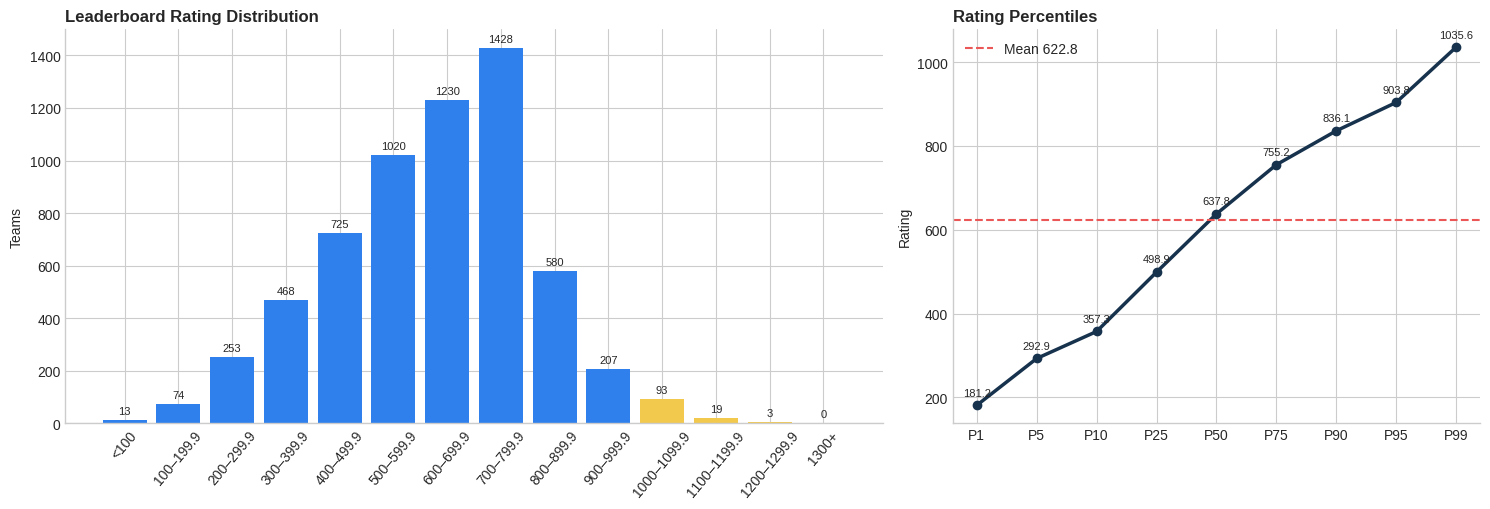

In [3]:
summary = pd.DataFrame({
    "Metric": ["Teams", "Mean", "Population Standard Deviation", "Median", "Minimum", "Maximum"],
    "value": [LEADERBOARD[key] for key in
              ["teams", "mean", "population_stdev", "median", "minimum", "maximum"]],
}).rename(columns={"value": "Value"})
display(summary)

histogram = pd.Series(LEADERBOARD["histogram"], name="Teams")
percentiles = pd.Series(LEADERBOARD["percentiles"], name="Rating")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1.55, 1]})
colors = [GOLD if label.startswith(("1000", "1100", "1200", "1300")) else BLUE
          for label in histogram.index]
bars = axes[0].bar(histogram.index, histogram.values, color=colors, width=0.82)
axes[0].bar_label(bars, padding=3, fontsize=8)
axes[0].set_title("Leaderboard Rating Distribution", loc="left", weight="bold")
axes[0].set_ylabel("Teams")
axes[0].tick_params(axis="x", rotation=50)

axes[1].plot(percentiles.index, percentiles.values, marker="o", lw=2.5, color=NAVY)
axes[1].axhline(LEADERBOARD["mean"], color=RED, ls="--", lw=1.5,
                label=f'Mean {LEADERBOARD["mean"]:.1f}')
for x, y in zip(percentiles.index, percentiles.values):
    axes[1].annotate(f"{y:.1f}", (x, y), xytext=(0, 7),
                     textcoords="offset points", ha="center", fontsize=8)
axes[1].set_title("Rating Percentiles", loc="left", weight="bold")
axes[1].set_ylabel("Rating")
axes[1].legend(frameon=False)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

The median of 637.8 was higher than the mean of 622.8 because the left tail extends into
negative ratings and pulls the mean downward. P90 was 836.1, P95 was 903.8, and P99 was 1035.6.
P90 marks the boundary for the top 10% and roughly corresponds to the bronze-medal range under
Kaggle's standard competition medal thresholds, although the actual award rules vary by
competition. The population standard deviation of 186.6 describes the spread of the entire
leaderboard; it is not a measure of uncertainty in any individual submission's rating.

## 2. Matchmaking Timing by Rating Band for the Author's Submissions

From the author's submission history, one submission was selected whose final rating was close
to each band. Using a snapshot saved at 2026-08-02 10:20 JST, the table summarizes the observed
rating, submission time, number of public matches, record, win rate, and observation window for
the 800, 700, 600, and 500 bands. The submissions rated 1000+ and around 900 are examined in more
detail in Sections 3 and 4.

The comparisons from this section onward are based on the public match history saved for each
submission. The submissions were not all observed at the same point in time.

The first heatmap covers submissions in the 1000+ through 500 bands. It treats submission time
as hour zero and aggregates the start times of Public Episodes into one-hour buckets. A common
color scale makes the 1000+ submission directly comparable with submissions rated 900 or lower.
The second heatmap uses the same time window for three historical 1000+ submissions. Each number
is the count of matches in that bucket; `-` denotes a bucket after the final observed public
match. Validation Episodes are excluded.

,Rating Band,Observed Rating,Submitted At (JST),Public Matches,Record,Win Rate,Hours to First Match,Observation Window to Final Public Match (h)
0,1000+,1155.1,2026-08-01 13:10:53,260,159-101,61.2%,0.05,21.67
1,900,928.0,2026-08-01 13:10:50,75,49-26,65.3%,0.05,21.54
2,800,801.1,2026-07-27 22:18:14,71,38-33,53.5%,0.05,24.28
3,700,719.7,2026-07-27 22:57:47,64,37-27,57.8%,0.06,23.68
4,600,592.6,2026-07-20 18:00:28,55,27-28,49.1%,0.08,18.02
5,500,475.8,2026-07-17 22:55:10,35,16-19,45.7%,0.07,12.89


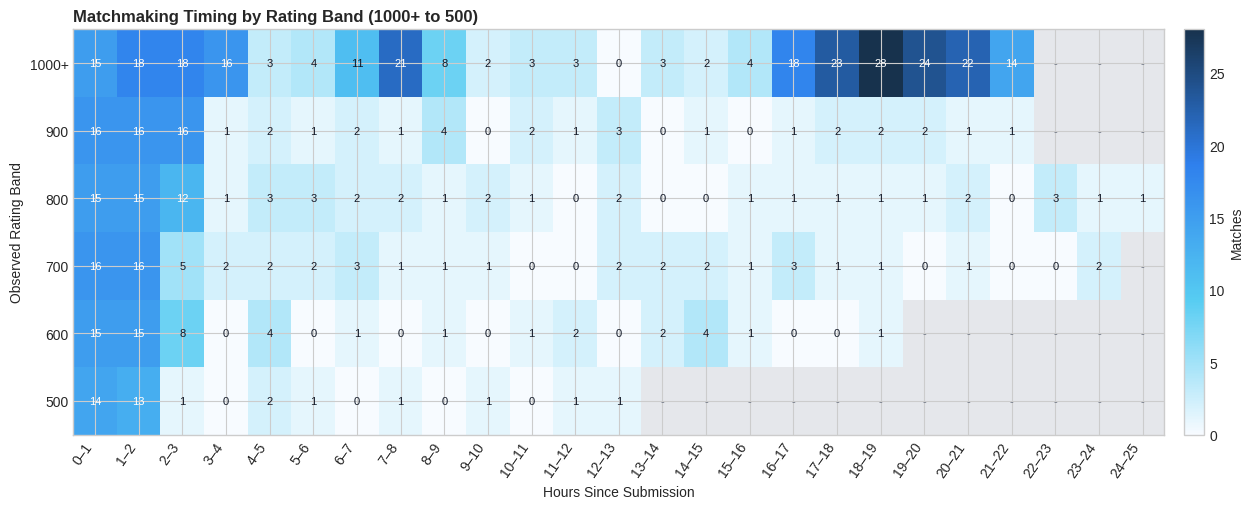

In [4]:
timing = pd.DataFrame(TIMING)
timing["first_3h_games"] = timing["hourly_counts"].map(lambda values: sum(values[:3]))
timing["first_3h_share"] = timing["first_3h_games"] / timing["public_games"]
reference_summary = pd.DataFrame(REFERENCE_BANDS)
reference_summary["record"] = reference_summary.apply(
    lambda row: f'{row["wins"]}-{row["losses"]}', axis=1
)
reference_summary["win_rate"] = reference_summary["win_rate"].map(lambda value: f"{value:.1f}%")
reference_summary = reference_summary[[
    "rating_band", "observed_rating", "submitted_at_jst", "public_games",
    "record", "win_rate", "first_match_hours", "last_match_hours",
]]
reference_summary.columns = [
    "Rating Band", "Observed Rating", "Submitted At (JST)", "Public Matches",
    "Record", "Win Rate", "Hours to First Match",
    "Observation Window to Final Public Match (h)",
]
display(reference_summary)

mid_timing = timing[
    timing["rating_band"].isin(["1000+", "900", "800", "700", "600", "500"])
].copy()
heat = np.array(mid_timing["hourly_counts"].tolist())
hours = np.arange(heat.shape[1])
inactive = hours[None, :] > np.floor(mid_timing["last_match_hours"].to_numpy())[:, None]
heat_display = np.ma.array(heat, mask=inactive)
cmap = LinearSegmentedColormap.from_list("matchmaking", ["#f7fbff", CYAN, BLUE, NAVY])
cmap.set_bad("#e5e7eb")
fig, ax = plt.subplots(figsize=(14, 5.2))
image = ax.imshow(heat_display, aspect="auto", cmap=cmap)
for row in range(heat.shape[0]):
    for hour in range(heat.shape[1]):
        if inactive[row, hour]:
            ax.text(hour, row, "-", ha="center", va="center", fontsize=8,
                    color="#6b7280")
            continue
        value = int(heat[row, hour])
        ax.text(hour, row, str(value), ha="center", va="center", fontsize=8,
                color="white" if value >= 12 else "#111827")
ax.set_yticks(range(len(mid_timing)), mid_timing["rating_band"])
ax.set_xticks(range(25), [f"{h}–{h+1}" for h in range(25)], rotation=55, ha="right")
ax.set_title("Matchmaking Timing by Rating Band (1000+ to 500)",
             loc="left", weight="bold")
ax.set_xlabel("Hours Since Submission")
ax.set_ylabel("Observed Rating Band")
fig.colorbar(image, ax=ax, label="Matches", pad=0.015)
plt.tight_layout()
plt.show()

### 2.1 Three Historical Submissions Rated 1000 or Higher

To determine whether the pattern was unique to a single submission, three historical submissions
rated 1000 or higher are compared with their Submission IDs withheld. The table shows the
observed rating, submission time, number of matches in the first 25 hours, total public matches,
and time until the final public match. To keep the heatmap comparison consistent, only the first
25 hours after each submission are shown.

,Observed Rating,Submitted At (JST),Matches in First 25 Hours,Total Public Matches,Hours to Final Public Match
0,1155.1,2026-08-01 13:10:53,260,260,21.67
1,1156.9,2026-07-30 18:43:27,177,368,41.84
2,1054.1,2026-06-21 14:39:02,152,415,244.82


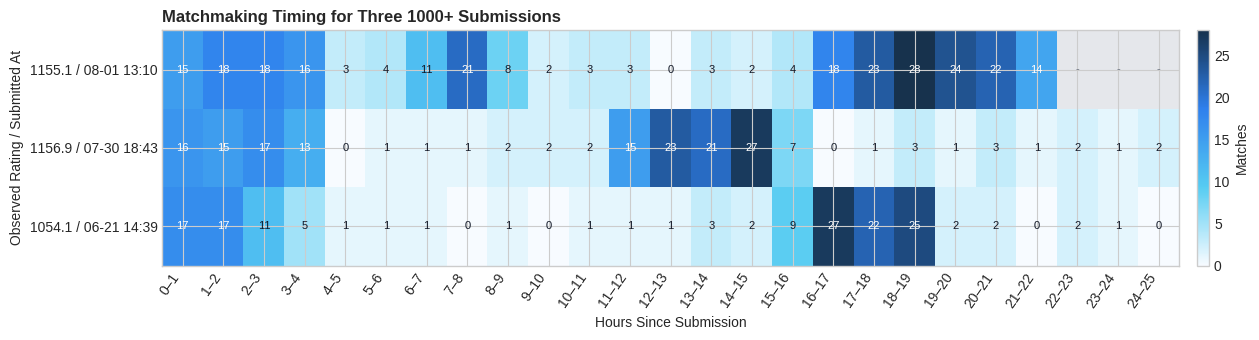

In [5]:
high_rating = pd.DataFrame(HIGH_RATING_TIMING)
high_rating["label"] = high_rating.apply(
    lambda row: f'{row["observed_rating"]:.1f} / {row["submitted_at_jst"][5:16]}', axis=1
)
high_rating_summary = high_rating[[
    "observed_rating", "submitted_at_jst", "games_first_25h",
    "public_games", "last_match_hours",
]].copy()
high_rating_summary.columns = [
    "Observed Rating", "Submitted At (JST)", "Matches in First 25 Hours",
    "Total Public Matches", "Hours to Final Public Match",
]
display(high_rating_summary)

high_heat = np.array(high_rating["hourly_counts"].tolist())
high_hours = np.arange(high_heat.shape[1])
high_inactive = (
    high_hours[None, :]
    > np.floor(high_rating["last_match_hours"].to_numpy())[:, None]
)
high_heat_display = np.ma.array(high_heat, mask=high_inactive)
fig, ax = plt.subplots(figsize=(14, 3.5))
image = ax.imshow(high_heat_display, aspect="auto", cmap=cmap)
for row in range(high_heat.shape[0]):
    for hour in range(high_heat.shape[1]):
        if high_inactive[row, hour]:
            ax.text(hour, row, "-", ha="center", va="center", fontsize=8,
                    color="#6b7280")
            continue
        value = int(high_heat[row, hour])
        ax.text(hour, row, str(value), ha="center", va="center", fontsize=8,
                color="white" if value >= 12 else "#111827")
ax.set_yticks(range(len(high_rating)), high_rating["label"])
ax.set_xticks(range(25), [f"{h}–{h+1}" for h in range(25)], rotation=55, ha="right")
ax.set_title("Matchmaking Timing for Three 1000+ Submissions",
             loc="left", weight="bold")
ax.set_xlabel("Hours Since Submission")
ax.set_ylabel("Observed Rating / Submitted At")
fig.colorbar(image, ax=ax, label="Matches", pad=0.015)
plt.tight_layout()
plt.show()

In most rating bands, matches were concentrated in the first 0–2 hours after submission. The
three 1000+ submissions received 51, 48, and 45 matches, respectively, in their first three hours.
The two submissions rated around 1150 also had a second concentration of matches at hours 16–21
and 11–15, while the submission rated around 1050 had a second concentration at hours 15–19.

Because all three showed both an immediate burst and renewed activity roughly half a day later,
the observations suggest that matches may resume or continue over a longer period for submissions
rated 1000 or higher. However, all three were the author's own submissions, and the agent,
submission date, public availability window, and opponent pool were not controlled. These data
alone cannot establish high rating as the cause.

## 3. Observation of More Public Matches at Ratings of 1000 or Higher

The chart on the left shows the public match count for each submission, while the chart on the
right shows the observation window from submission to the final public match. The main comparison
is between Submission A, rated 1000+, and Submission B, rated around 900. They used the same
submission artifact and were submitted three seconds apart.

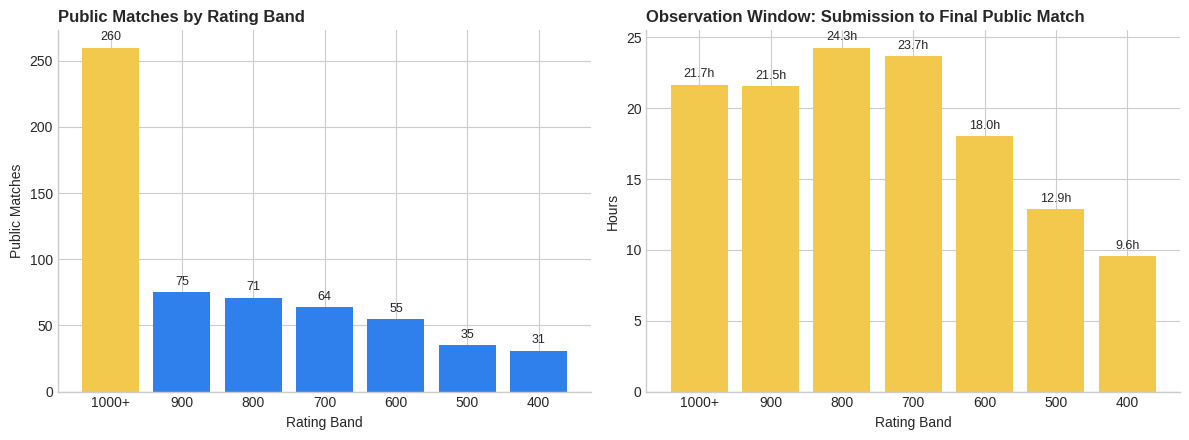

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
bar_colors = [GOLD if band == "1000+" else BLUE for band in timing["rating_band"]]
axes[0].bar(timing["rating_band"], timing["public_games"], color=bar_colors)
axes[0].set_title("Public Matches by Rating Band", loc="left", weight="bold")
axes[0].set_ylabel("Public Matches")
axes[0].bar_label(axes[0].containers[0], padding=3, fontsize=9)
axes[1].bar(timing["rating_band"], timing["last_match_hours"], color=GOLD)
axes[1].set_title("Observation Window: Submission to Final Public Match",
                  loc="left", weight="bold")
axes[1].set_ylabel("Hours")
axes[1].bar_label(axes[1].containers[0], fmt="%.1fh", padding=3, fontsize=9)
for ax in axes:
    ax.set_xlabel("Rating Band")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Submission A received 260 matches and Submission B received 75, a difference of about 3.5 times.
Their observation windows to the final public match were nearly identical, at about 21.7 and
21.5 hours. The 185-match difference therefore cannot be explained by observation-window length
alone. The next section isolates these two closely matched submissions and compares their early
results, rating trajectories, and rematch counts.

## 4. Divergence Between Two Submissions of the Same Deck Made at Nearly the Same Time

Submission A and Submission B used the same submission artifact containing the same battle agent
and deck. They were submitted to Kaggle three seconds apart, and both started at a
rating of 600.

### 4.1 The Importance of the First Few Matches

The table shows the submission time, rating after the first, sixth, and 48th matches, total public
matches, and observation window. Using the saved public match history, the charts compare the
cumulative win rate and rating trajectory over the first 48 matches.

,Submission,Submitted At (JST),First Match,Rating After First Match,First Six Matches,Rating After Six Matches,Rating After 48 Matches,Public Matches,Observation Window to Final Public Match (h)
0,Submission A,2026-08-01 13:10:53,Win,689,6-0,1011,1150,260,21.67
1,Submission B,2026-08-01 13:10:50,Loss,489,3-3,642,867,75,21.54


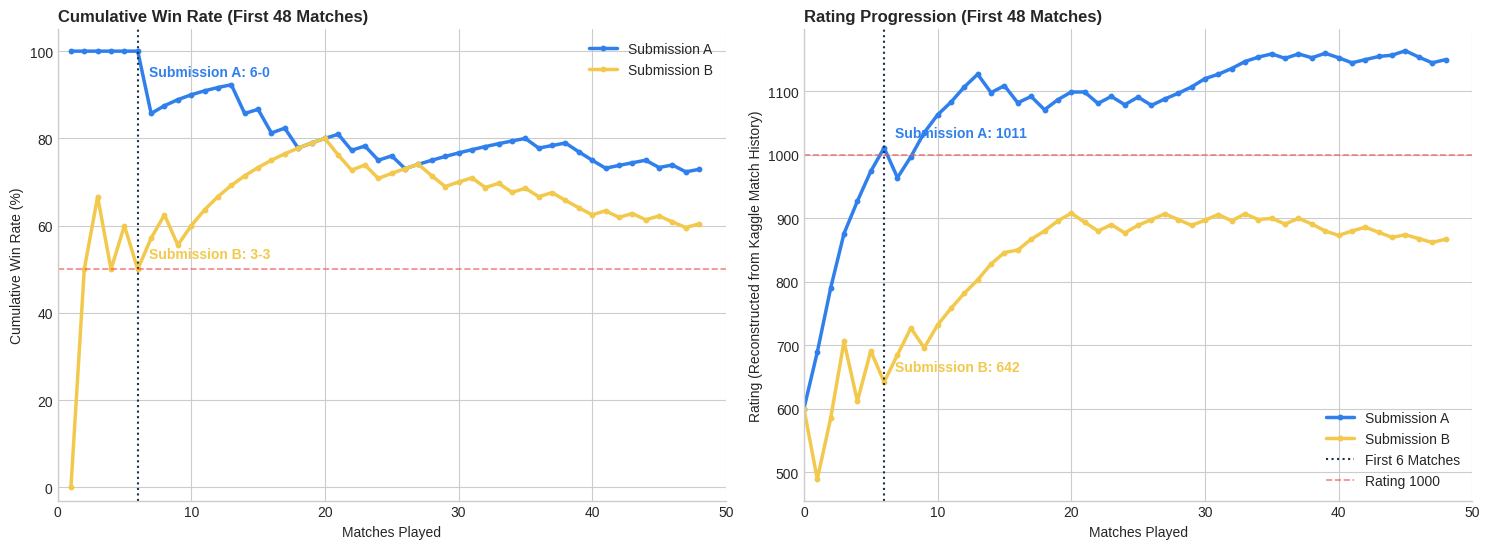

In [7]:
submission_rows = []
for key in ["submission_a", "submission_b"]:
    submission = IDENTICAL_SUBMISSIONS[key]
    submission_rows.append({
        "Submission": submission["label"],
        "Submitted At (JST)": submission["submitted_at_jst"],
        "First Match": "Win" if submission["outcomes_first_48"][0] == "W" else "Loss",
        "Rating After First Match": int(submission["ratings_first_48"][1]),
        "First Six Matches": submission["first_6_record"],
        "Rating After Six Matches": int(submission["rating_at_6"]),
        "Rating After 48 Matches": int(submission["rating_at_48"]),
        "Public Matches": submission["public_games"],
        "Observation Window to Final Public Match (h)": submission["last_match_hours"],
    })
submission_summary = pd.DataFrame(submission_rows)
display(submission_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
for key, color in [("submission_a", BLUE), ("submission_b", GOLD)]:
    submission = IDENTICAL_SUBMISSIONS[key]
    outcomes = np.array([result == "W" for result in submission["outcomes_first_48"]])
    games = np.arange(1, len(outcomes) + 1)
    cumulative_win_rate = np.cumsum(outcomes) / games * 100
    axes[0].plot(games, cumulative_win_rate, color=color, lw=2.5,
                 marker="o", markersize=3.2, label=submission["label"])

    rating_games = np.arange(len(submission["ratings_first_48"]))
    axes[1].plot(rating_games, submission["ratings_first_48"], color=color, lw=2.5,
                 marker="o", markersize=3.2, label=submission["label"])
    axes[1].annotate(f'{submission["label"]}: {int(submission["rating_at_6"])}',
                     (6, submission["rating_at_6"]), xytext=(8, 8),
                     textcoords="offset points", color=color, weight="bold")

axes[0].axvline(6, color=NAVY, ls=":", lw=1.5)
axes[0].axhline(50, color=RED, ls="--", lw=1.2, alpha=0.7)
axes[0].annotate("Submission A: 6-0", (6, 100), xytext=(8, -18),
                 textcoords="offset points", color=BLUE, weight="bold")
axes[0].annotate("Submission B: 3-3", (6, 50), xytext=(8, 8),
                 textcoords="offset points", color=GOLD, weight="bold")
axes[0].set_title("Cumulative Win Rate (First 48 Matches)", loc="left", weight="bold")
axes[0].set_ylabel("Cumulative Win Rate (%)")
axes[0].set_ylim(-3, 105)

axes[1].axvline(6, color=NAVY, ls=":", lw=1.5, label="First 6 Matches")
axes[1].axhline(1000, color=RED, ls="--", lw=1.2, alpha=0.7,
                label="Rating 1000")
axes[1].set_title("Rating Progression (First 48 Matches)", loc="left", weight="bold")
axes[1].set_ylabel("Rating (Reconstructed from Kaggle Match History)")

for ax in axes:
    ax.set_xlabel("Matches Played")
    ax.set_xlim(0, 50)
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Submission A won its first match and moved to 689, while Submission B lost and moved to 489,
creating a 200-point gap after a single match. Over the first six matches, Submission A went 6–0
and Submission B went 3–3, widening the gap to 369 points. Both accumulated wins and losses after
that, but a 283-point gap remained after 48 matches.

In this example, the early divergence remained visible in the later rating and matchmaking paths.
Because the submissions faced different opponents, however, the first result alone cannot be
identified as the cause.

### 4.2 Difference Between Total Matches and Rematches

A "rematch" is any second or later match against the same opponent team within one submission.
The public match count is split into the number of opponent teams encountered for the first time
and the number of rematches.

,Submission,Public Matches,Unique Opponent Teams,Opponent Teams Seen at Least Twice,Rematches After First Encounter,Maximum Matches Against One Team,Rematch Share
0,Submission A,260,100,45,160,30,0.615385
1,Submission B,75,71,4,4,2,0.053333


,Metric,Count
0,Shared Opponent Teams,3
1,Pairable Matches Against the Same Team,3
2,Shared Opponent Submissions,0
3,Pairable Matches Against the Same Opponent Sub...,0


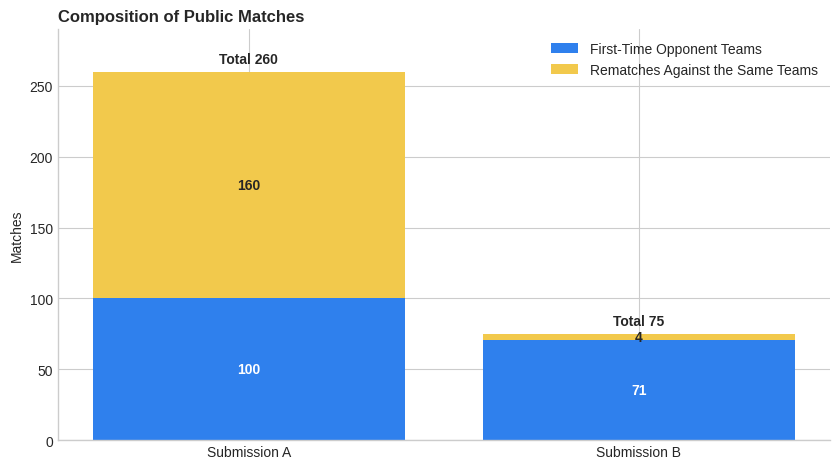

In [8]:
repeats = pd.DataFrame([
    {"Submission": "Submission A", **REPEAT_MATCHES["submission_a"]},
    {"Submission": "Submission B", **REPEAT_MATCHES["submission_b"]},
])
repeats["repeat_game_share"] = repeats["repeat_games_after_first"] / repeats["public_games"]
display(repeats.rename(columns={
    "public_games": "Public Matches",
    "unique_opponent_teams": "Unique Opponent Teams",
    "opponent_teams_seen_2plus": "Opponent Teams Seen at Least Twice",
    "repeat_games_after_first": "Rematches After First Encounter",
    "max_games_vs_one_team": "Maximum Matches Against One Team",
    "repeat_game_share": "Rematch Share",
}))

overlap = pd.DataFrame({
    "Metric": ["Shared Opponent Teams", "Pairable Matches Against the Same Team",
               "Shared Opponent Submissions",
               "Pairable Matches Against the Same Opponent Submission"],
    "Count": [REPEAT_MATCHES["shared_opponent_teams"],
              REPEAT_MATCHES["pairable_games_same_team"],
              REPEAT_MATCHES["shared_opponent_submissions"],
              REPEAT_MATCHES["pairable_games_same_submission"]],
})
display(overlap)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
first_encounters = ax.bar(repeats["Submission"], repeats["unique_opponent_teams"],
                          color=BLUE, label="First-Time Opponent Teams")
repeat_games = ax.bar(repeats["Submission"], repeats["repeat_games_after_first"],
                      bottom=repeats["unique_opponent_teams"],
                      color=GOLD, label="Rematches Against the Same Teams")
ax.bar_label(first_encounters, label_type="center", color="white", weight="bold")
ax.bar_label(repeat_games, label_type="center", weight="bold")
for index, total in enumerate(repeats["public_games"]):
    ax.text(index, total + 6, f"Total {total}", ha="center", weight="bold")
ax.set_title("Composition of Public Matches", loc="left", weight="bold")
ax.set_ylabel("Matches")
ax.set_ylim(0, 290)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Submission A's 260 matches consisted of first encounters with 100 teams and 160 rematches.
Submission B's 75 matches consisted of first encounters with 71 teams and four rematches.
Of the 185-match difference between the submissions, 156 matches (about 84%) came from the
difference in rematches.

Only three opponent teams appeared in both submissions, and there were no matches against the
same submission artifact from the same opponent. Thus, even when the same artifact was submitted
at nearly the same time, both the opponents assigned after the early matches and the number of
rematches differed substantially.

## Notes

- Only Public Episodes are included; Validation Episodes are excluded.
- Rating trajectories were reconstructed from Kaggle match history and may contain rounding
  error of approximately ±1 point.

## Takeaways

Differences in matchmaking timing and public match volume were observed across rating bands.
However, these are descriptive observations from a small number of the author's submissions made
on or before August 1, 2026. They do not establish that a higher rating causes changes in
matchmaking time or match volume.